### ==========================================
### 1. Data Validation & Cleaning
### ==========================================

In [69]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load datasets
activity = pd.read_csv('C:\\Users\\hp\\Desktop\\fitly_user_activity.csv')
account = pd.read_csv('C:\\Users\\hp\\Desktop\\fitly_account_info.csv')
support = pd.read_csv('C:\\Users\\hp\\Desktop\\fitly_customer_support.csv')

In [70]:
# Merge all datasets
df = account.merge(activity, on='user_id', how='left') \
            .merge(support, on='user_id', how='left')
        
df.info()
df.isnull().mean()*100  # % of measing value

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1441 entries, 0 to 1440
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   customer_id            1441 non-null   object 
 1   user_id                1441 non-null   int64  
 2   email                  1441 non-null   object 
 3   state_x                1441 non-null   object 
 4   plan                   1441 non-null   object 
 5   plan_list_price        1441 non-null   int64  
 6   churn_status           301 non-null    object 
 7   event_time             1063 non-null   object 
 8   event_type             1063 non-null   object 
 9   ticket_time            1390 non-null   object 
 10  channel                1390 non-null   object 
 11  topic                  1390 non-null   object 
 12  resolution_time_hours  1390 non-null   float64
 13  state_y                1390 non-null   float64
 14  comments               67 non-null     object 
dtypes: f

customer_id               0.000000
user_id                   0.000000
email                     0.000000
state_x                   0.000000
plan                      0.000000
plan_list_price           0.000000
churn_status             79.111728
event_time               26.231783
event_type               26.231783
ticket_time               3.539209
channel                   3.539209
topic                     3.539209
resolution_time_hours     3.539209
state_y                   3.539209
comments                 95.350451
dtype: float64

### Cleaning Steps:



<AxesSubplot:>

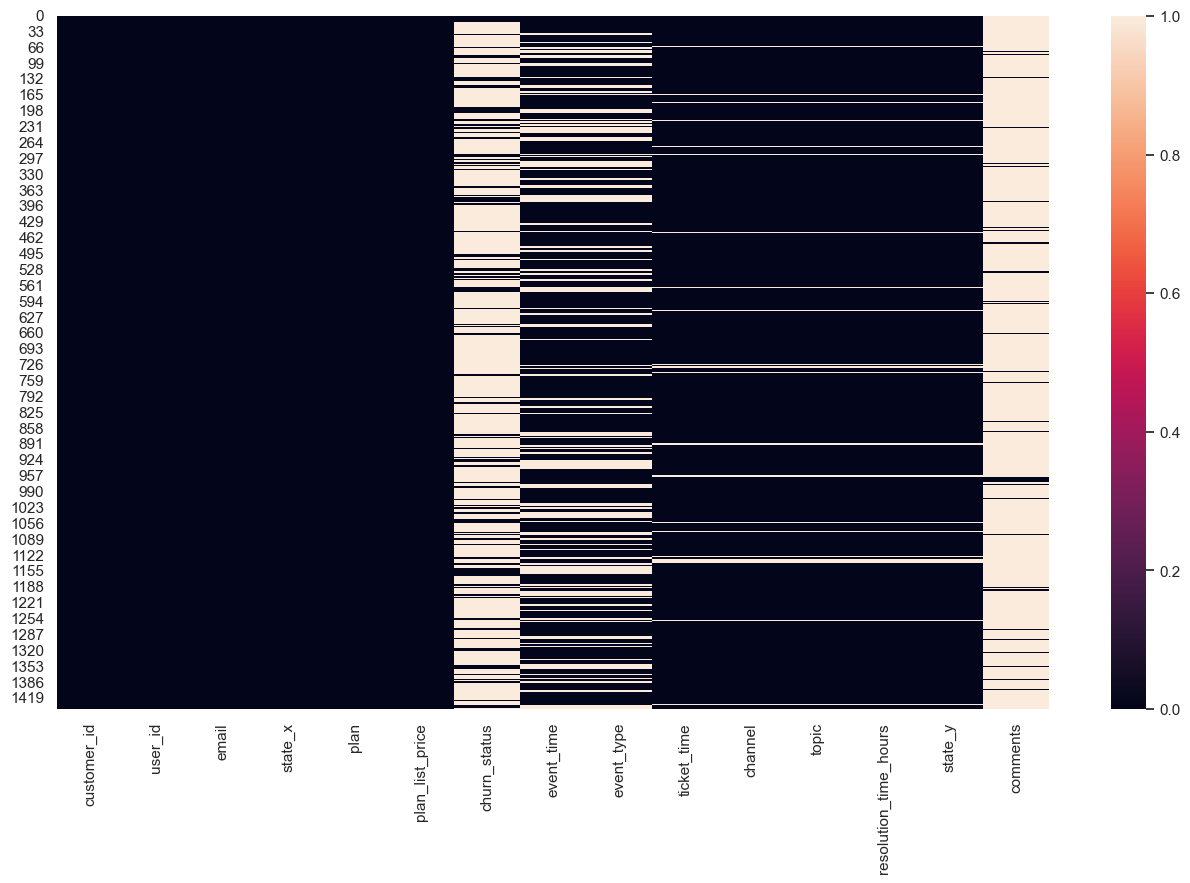

In [71]:
# visualize missing value using heatmap to get idea where is the value missing

plt.figure(figsize=(16,9))
sns.heatmap(df.isnull())

In [72]:
df['churn_status'] = df['churn_status'].replace('Y', 'Yes')
# Fill missing values  ## other than 'Yes' are 'No'
df['churn_status'].fillna('No', inplace=True)

In [73]:
# 1. Drop columns with high missing values (>70% or specific to the business logic)
df = df.drop(['event_time','comments'], axis='columns')


In [74]:
df.isnull().mean()*100

customer_id               0.000000
user_id                   0.000000
email                     0.000000
state_x                   0.000000
plan                      0.000000
plan_list_price           0.000000
churn_status              0.000000
event_type               26.231783
ticket_time               3.539209
channel                   3.539209
topic                     3.539209
resolution_time_hours     3.539209
state_y                   3.539209
dtype: float64

In [75]:
# 2. Impute missing categorical values with the Mode
# Calculate the mode and select the first value
mode_value = df['event_type'].mode()[0]

# Fill missing values
df['event_type'].fillna(mode_value, inplace=True)

In [76]:
# 3. Drop rows with missing support data (approx 3.5% of records)
df.dropna(inplace=True)
df.isnull().mean()*100

customer_id              0.0
user_id                  0.0
email                    0.0
state_x                  0.0
plan                     0.0
plan_list_price          0.0
churn_status             0.0
event_type               0.0
ticket_time              0.0
channel                  0.0
topic                    0.0
resolution_time_hours    0.0
state_y                  0.0
dtype: float64

In [77]:
# # Validate data types
df['resolution_time_hours'] = df['resolution_time_hours'].astype(float)

In [78]:
# Replace blank '-' with mode
mode=df['channel'].mode()[0]
df['channel'] = df['channel'].replace('-', mode)

In [79]:
df['channel'].value_counts()

chat     525
email    438
phone    427
Name: channel, dtype: int64

In [80]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1390 entries, 0 to 1440
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   customer_id            1390 non-null   object 
 1   user_id                1390 non-null   int64  
 2   email                  1390 non-null   object 
 3   state_x                1390 non-null   object 
 4   plan                   1390 non-null   object 
 5   plan_list_price        1390 non-null   int64  
 6   churn_status           1390 non-null   object 
 7   event_type             1390 non-null   object 
 8   ticket_time            1390 non-null   object 
 9   channel                1390 non-null   object 
 10  topic                  1390 non-null   object 
 11  resolution_time_hours  1390 non-null   float64
 12  state_y                1390 non-null   float64
dtypes: float64(2), int64(2), object(9)
memory usage: 152.0+ KB


In [81]:
df_clean_data = df.copy()

In [82]:
df_clean_data.to_csv('cleaned_data.csv', index=False)

### ==========================================
### 2. Exploratory Analysis Visualizations
### ==========================================

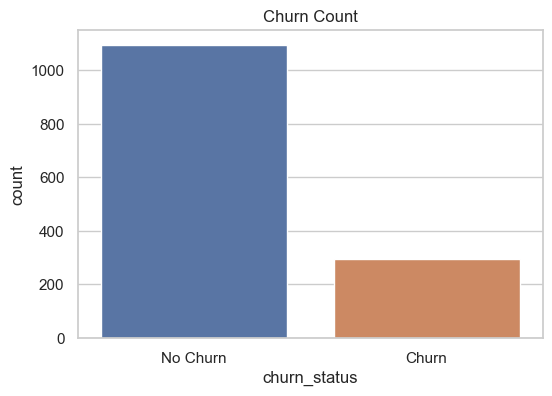

In [83]:
# Convert churn_status to numeric (Yes=1, No=0)
df['churn_status'] = df['churn_status'].map({'Yes': 1, 'No': 0})
# 1. Bar chart: Count of churned vs non-churned customers
plt.figure(figsize=(6,4))
sns.countplot(x='churn_status', data=df)
plt.xticks([0,1], ['No Churn','Churn'])
plt.title("Churn Count")
plt.show()

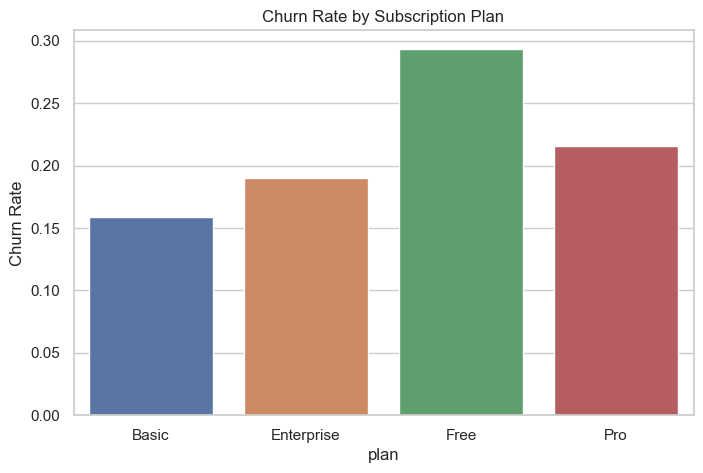

In [84]:
# Churn rate by subscription plan
plt.figure(figsize=(8,5))
churn_plan = df.groupby('plan')['churn_status'].mean().reset_index()
sns.barplot(x='plan', y='churn_status', data=churn_plan)
plt.title("Churn Rate by Subscription Plan")
plt.ylabel("Churn Rate")
plt.show()

This graph shows that churn varies a lot depending on the subscription plan. Customers on the **Free plan** are leaving at the highest rate, which suggests that free users are less committed and more likely to drop off. The **Pro plan** also has a relatively high churn rate, meaning paying customers at this tier may not see enough value for the price. The **Enterprise plan** performs better, with lower churn, and the **Basic plan** has the lowest churn rate overall, showing stronger retention among entry-level subscribers. The key insight is that churn risk is concentrated in the Free and Pro tiers, so improving the value proposition for those groups could significantly reduce overall customer loss.

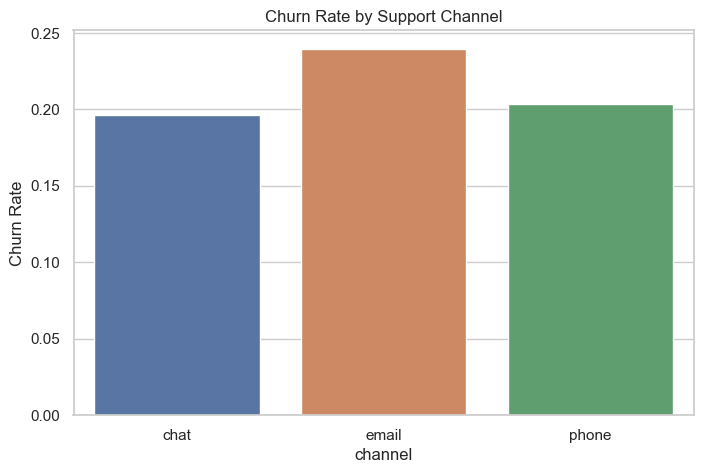

In [85]:
# Churn rate by support channel
plt.figure(figsize=(8,5))
churn_channel = df.groupby('channel')['churn_status'].mean().reset_index()
sns.barplot(x='channel', y='churn_status', data=churn_channel)
plt.title("Churn Rate by Support Channel")
plt.ylabel("Churn Rate")
plt.show()

Customers who rely on email support have the highest churn rate, which suggests that email may feel slower, less personal, or less effective in resolving issues, possibly because email support can be time-consuming or frustrating if resolution takes too long. In contrast, phone and chat support have the lowest churn rate, indicating that customers value quick, convenient, and interactive help.

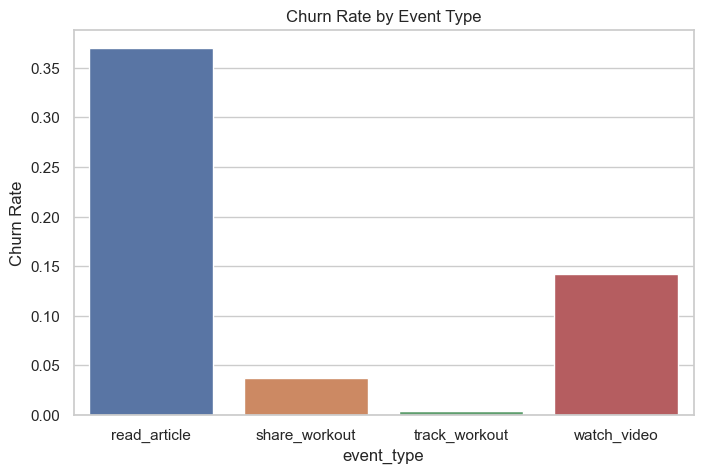

In [86]:
# Churn rate by event_type
plt.figure(figsize=(8,5))
churn_event = df.groupby('event_type')['churn_status'].mean().reset_index()
sns.barplot(x='event_type', y='churn_status', data=churn_event)
plt.title("Churn Rate by Event Type")
plt.ylabel("Churn Rate")
plt.show()

Customers who watch videos also show a less churn rate than those customer who mainly read articles, meaning video content helps retention but still leaves room for improvement. On the other hand, users who share workouts have a very low churn rate, and those who track workouts almost never churn.
Customers who actively engage with interactive or personal activities (like tracking or sharing workouts) are far more loyal, while passive activities (like reading articles) are tied to higher churn. This means the business should encourage more interactive engagement features, promote workout tracking/sharing, and rethink how article or video content can be made more engaging to reduce churn.

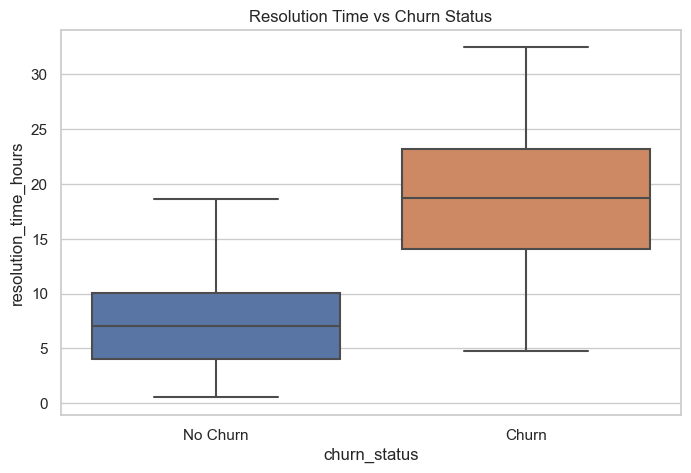

In [87]:
# Resolution time distribution for churned vs non-churned customers
plt.figure(figsize=(8,5))
sns.boxplot(x='churn_status', y='resolution_time_hours', data=df)
plt.xticks([0,1], ['No Churn','Churn'])
plt.title("Resolution Time vs Churn Status")
plt.show()

This graph makes it clear that resolution time is strongly linked to churn. Customers who did not churn had their issues resolved much faster, with a median resolution time of about 6 hours and most cases falling within 4–10 hours. In contrast, customers who churned experienced much longer resolution times, with a median around 18 hours and many cases stretching beyond 20 hours.

Key insight: Delays in resolving customer issues are a major driver of churn. When problems take too long to fix, customers lose trust and are more likely to leave. This means that improving support efficiency reducing resolution times and ensuring quicker responses can directly improve retention and lower churn. In short, faster problem-solving equals stronger customer loyalty.

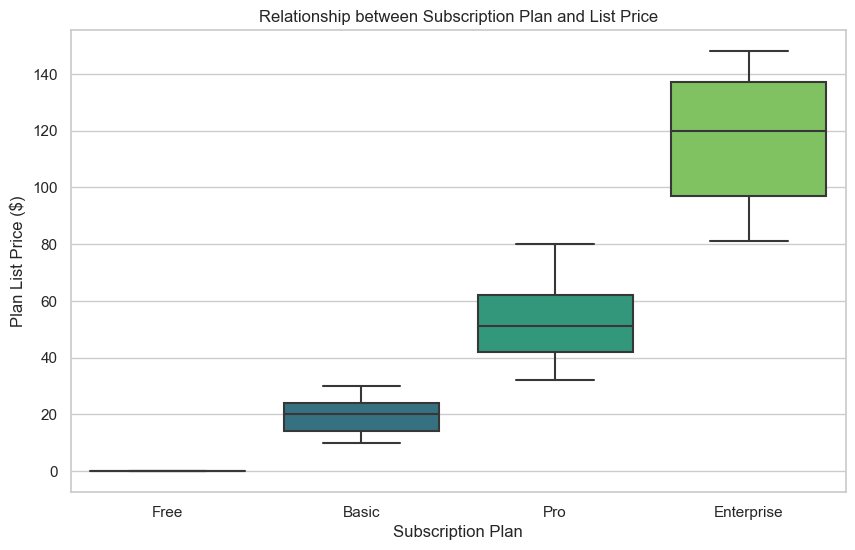

In [88]:
# Relationship between subscription plan and list price
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='plan', y='plan_list_price', palette='viridis', 
            order=['Free', 'Basic', 'Pro', 'Enterprise'])
plt.title('Relationship between Subscription Plan and List Price')
plt.xlabel('Subscription Plan')
plt.ylabel('Plan List Price ($)')

# Save the plot
plt.show()

The pricing data shows a clear step-by-step increase across the plans. The Free plan is always $0. The Basic plan usually costs between $10 and $30, while the Pro plan ranges from about $30 to $80. The Enterprise plan is the most expensive, with prices between $80 and $140. This setup makes it easy to see the differences between each tier. Basic and Pro have steady, fixed prices for smaller users, while Enterprise is more flexible and negotiable for big organizations. Overall, the Free plan helps attract new users, Basic and Pro serve individuals and small businesses, and Enterprise is the premium option that brings in the most revenue.

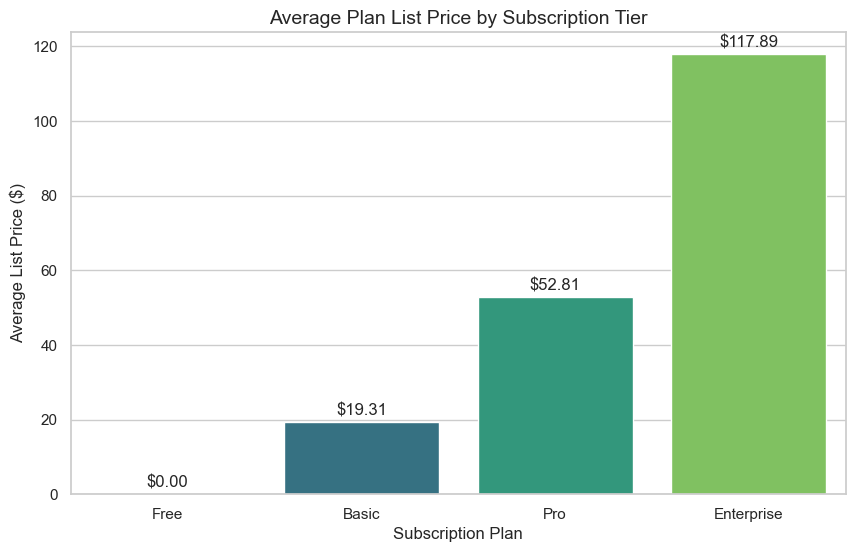

In [89]:
# Relationship between subscription plan and list price

# Calculate the average price per plan and sort
avg_price = df.groupby('plan')['plan_list_price'].mean().sort_values().reset_index()

# Create the bar graph
plt.figure(figsize=(10, 6))
sns.barplot(data=avg_price, x='plan', y='plan_list_price', palette='viridis')

# Add labels and title
plt.title('Average Plan List Price by Subscription Tier', fontsize=14)
plt.xlabel('Subscription Plan', fontsize=12)
plt.ylabel('Average List Price ($)', fontsize=12)

# Add data labels on top of each bar
for i, value in enumerate(avg_price['plan_list_price']):
    plt.text(i, value + 1, f'${value:.2f}', ha='center', va='bottom')

# Save the plot
plt.show()

The graph shows that the average subscription price rises clearly with each tier. The Free plan is always $0, which works as a way to attract new users. The Basic plan averages about $19, making it a low-cost upgrade for individuals. The Pro plan increases to around $53, aimed at professionals or small businesses. Finally, the Enterprise plan is the highest at about $118, showing it is a premium option for large organizations with flexible pricing. Overall, this step-by-step increase highlights a clear pricing ladder: Free brings users in, Basic and Pro provide affordable and predictable options, and Enterprise delivers the most revenue potential by targeting big clients.

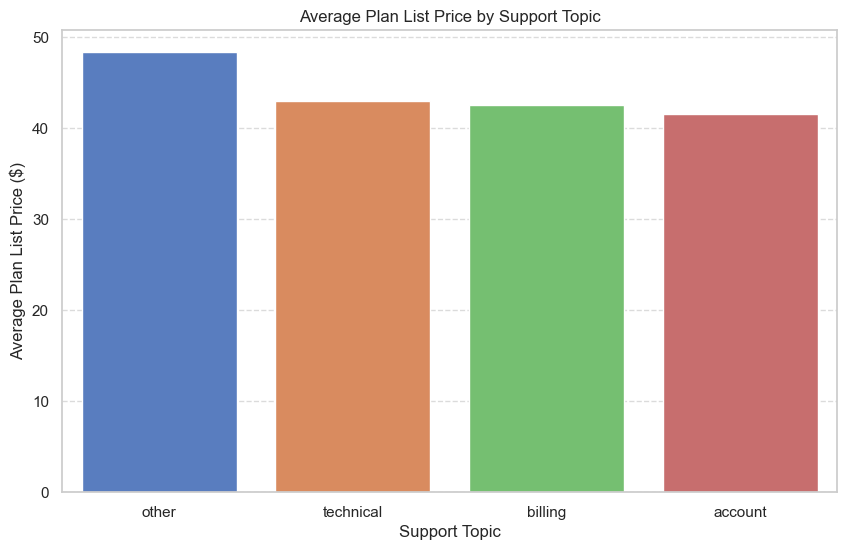

In [90]:
# Relationship between topic and list price
# Calculate the average plan list price per support topic
avg_price_topic = df.groupby('topic')['plan_list_price'].mean().sort_values(ascending=False).reset_index()

# Create the Bar Graph
plt.figure(figsize=(10, 6))
sns.barplot(x='topic', y='plan_list_price', data=avg_price_topic, palette='muted')

# Add titles and labels
plt.title('Average Plan List Price by Support Topic')
plt.xlabel('Support Topic')
plt.ylabel('Average Plan List Price ($)')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Save the plot as an image
plt.show()

The graph shows how average subscription prices vary depending on the support topic. Customers who contact support for “other” issues tend to have the highest average plan price, close to $50. In comparison, the topics “technical,” “billing,” and “account” all cluster around $42–$44, showing very similar average prices. This means that higher-value customers are more often linked to general or miscellaneous support requests, while those dealing with billing, technical, or account issues are spread across lower-priced plans. In simple terms, the chart highlights that premium users are more likely to raise “other” types of concerns, while everyday support topics like billing or technical issues are common across mid-range plans.

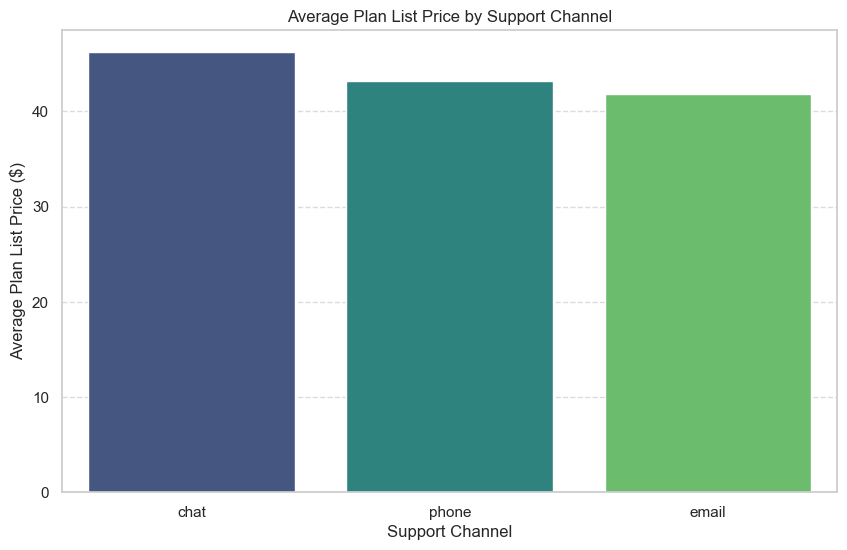

In [91]:
# Relationship between support channel and list price

# Aggregate data: Calculate mean price per channel and sort
channel_price_agg = df.groupby('channel')['plan_list_price'].mean().sort_values(ascending=False).reset_index()

# Create the Bar Graph
plt.figure(figsize=(10, 6))
sns.barplot(x='channel', y='plan_list_price', data=channel_price_agg, palette='viridis')

# Customizing titles and labels
plt.title('Average Plan List Price by Support Channel')
plt.xlabel('Support Channel')
plt.ylabel('Average Plan List Price ($)')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Save the plot
plt.show()

The bar chart comparing **average plan list price by support channel** shows that customers who use **chat support** tend to have the highest average plan prices (around $45), followed by those using **phone support** (around $43), while **email support** users have the lowest average (around $42). This suggests that higher-paying customers, often on Pro or Enterprise plans, are more likely to engage through chat, possibly because it offers faster, more interactive assistance. Phone support sits in the middle, reflecting a mix of both higher and lower-tier customers, while email support is more commonly used by lower-priced plan holders, who may prefer slower but cost-effective communication. The insight here is that support channel usage correlates with customer value: premium customers lean toward real-time channels like chat, while lower-tier customers rely more on email. This pattern highlights how service preferences can mirror customer segmentation and pricing tiers.

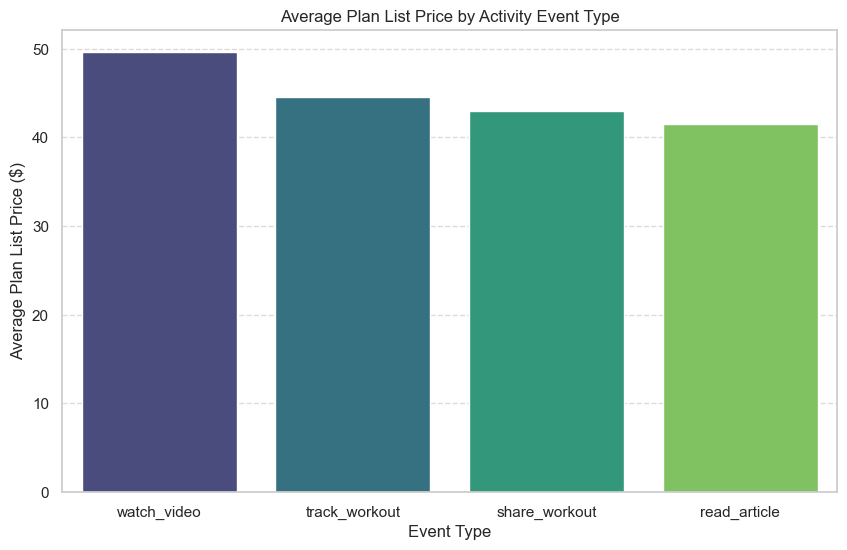

In [92]:
# Relationship between event type and list price

# Calculate the average plan list price per event type
avg_price_event = df.groupby('event_type')['plan_list_price'].mean().sort_values(ascending=False).reset_index()

# Create the Bar Graph
plt.figure(figsize=(10, 6))
sns.barplot(x='event_type', y='plan_list_price', data=avg_price_event, palette='viridis')

# Customizing titles and labels
plt.title('Average Plan List Price by Activity Event Type')
plt.xlabel('Event Type')
plt.ylabel('Average Plan List Price ($)')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Save the plot as an image
plt.show()

The graph shows how average subscription prices differ by activity type. Customers who **watch videos** have the highest average plan price, close to $50. Those who **track workouts** and **share workouts** are next, both around $45. Finally, customers who **read articles** have the lowest average, about $42. In simple terms, this means that higher-paying customers are more likely to engage with video content, while lower-priced plan users are more often linked to reading articles. The insight here is that premium users prefer richer, interactive activities like video and workout tracking, while budget users stick to simpler actions like reading. This pattern highlights how customer value is connected to the type of activity they engage in.

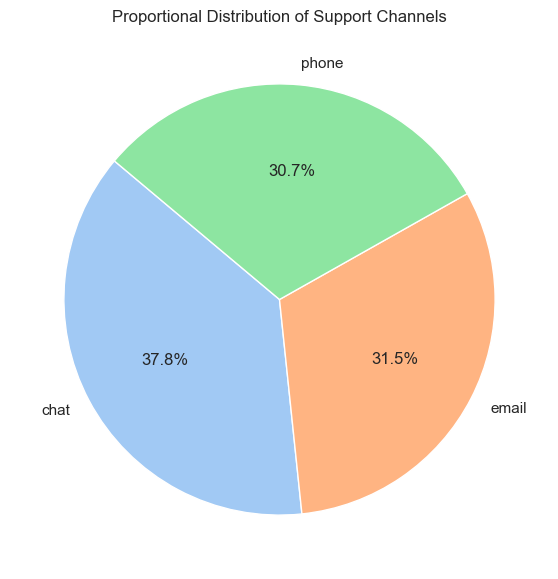

In [93]:
# Proportion of Support Channels (Pie Chart)
plt.figure(figsize=(7, 7))
channel_counts = df['channel'].value_counts()
plt.pie(channel_counts, labels=channel_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title('Proportional Distribution of Support Channels')
plt.show()

The pie chart showing the **proportional distribution of support channels** reveals that **chat support** is the most frequently used channel, accounting for 37.8% of interactions, followed by **email** at 31.5% and **phone** at 30.7%. This indicates that customers across different subscription tiers prefer real-time, interactive communication through chat, likely because it provides quicker resolutions compared to email or phone. The relatively balanced proportions between email and phone suggest that both remain important for customers who prefer more formal or direct communication. The insight here is that while all three channels are well utilized, chat stands out as the dominant choice, reflecting a broader trend toward instant digital support and highlighting the need for businesses to prioritize and strengthen their chat-based customer service systems.

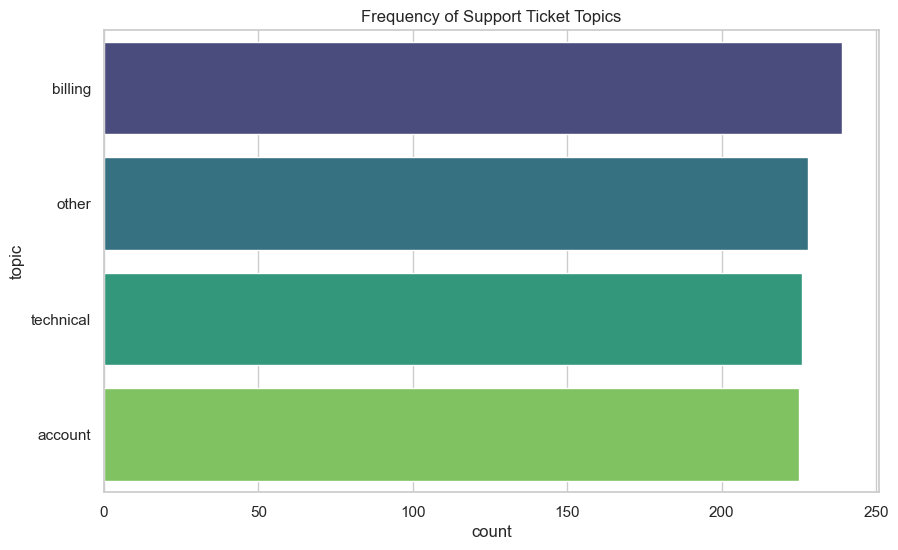

In [94]:
# Support Topic Frequency (Bar)
plt.figure(figsize=(10, 6))
sns.countplot(y='topic', data=support, order=support['topic'].value_counts().index, palette='viridis')
plt.title('Frequency of Support Ticket Topics')
plt.show()

The horizontal bar chart on **frequency of support ticket topics** shows that **billing issues** generate the highest number of tickets, followed by the “other” category, then technical issues, with **account-related queries** being the least frequent. This pattern suggests that billing concerns are the most common pain point across customers, cutting across all subscription tiers, while technical and account issues occur less often but still represent significant support needs. The “other” category’s high frequency indicates a wide range of miscellaneous concerns that don’t fit neatly into standard categories, reflecting diverse customer experiences. The key insight is that billing support requires the greatest resource allocation, as it dominates ticket volume, while technical and account support can be managed with relatively fewer resources. This distribution highlights where customer service teams should focus their efforts to improve satisfaction and efficiency.

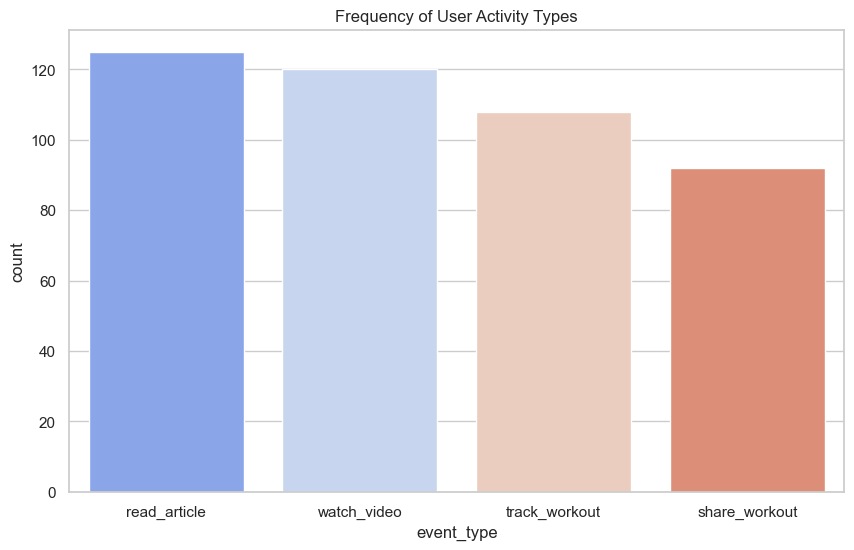

In [95]:
# Activity Event Type Distribution (Bar)
plt.figure(figsize=(10, 6))
sns.countplot(x='event_type', data=activity, order=activity['event_type'].value_counts().index, palette='coolwarm')
plt.title('Frequency of User Activity Types')
plt.show()

The bar chart on **frequency of user activity types** shows that **reading articles** is the most common activity, slightly above 120 occurrences, followed closely by **watching videos** at around 120, then **tracking workouts** at about 110, and finally **sharing workouts** at roughly 95. This distribution suggests that users across different subscription tiers engage most frequently with informational or content-driven activities like reading and watching, while interactive or social activities such as tracking and sharing workouts occur less often. The insight here is that content consumption dominates user behavior, highlighting the importance of maintaining a strong library of articles and videos to keep customers engaged, while workout-related features serve as valuable but secondary engagement drivers. This balance indicates that the platform’s core value lies in delivering accessible content, with fitness and sharing features providing added depth for more active users.

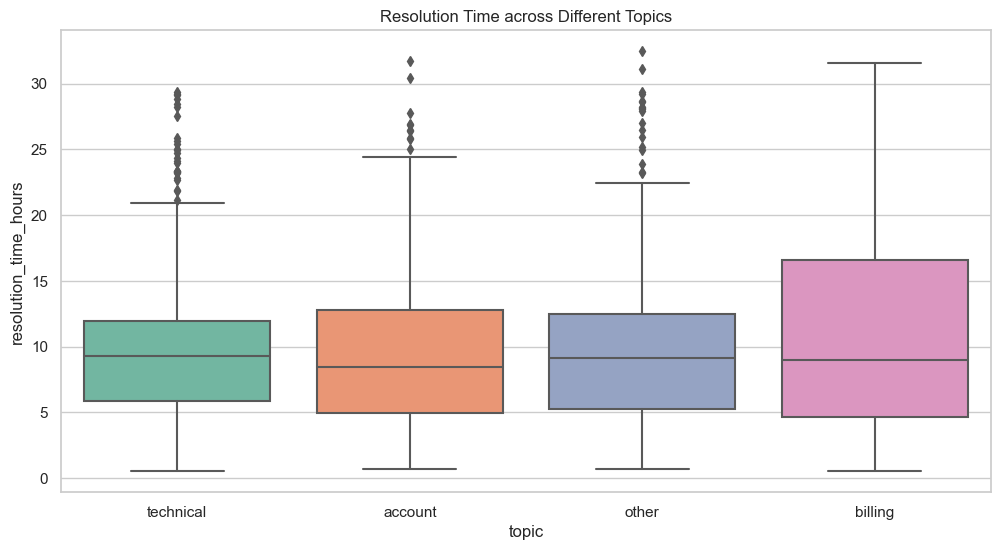

In [96]:
# Resolution Time by Topic (Boxplot)
plt.figure(figsize=(12, 6))
sns.boxplot(x='topic', y='resolution_time_hours', data=support, palette='Set2')
plt.title('Resolution Time across Different Topics')
plt.show()

The box plot on **resolution time across different support topics** shows clear differences in how long issues take to resolve. **Billing tickets** have the widest spread, with resolution times ranging from very short to nearly 30 hours, indicating inconsistency and potential inefficiencies in handling financial concerns. In contrast, **technical** and **other** topics have narrower distributions, suggesting more predictable resolution times, while **account-related issues** fall somewhere in between. The key insight is that billing problems are not only the most frequent (as seen in earlier charts) but also the most variable in resolution, making them a critical area for improvement. Streamlining billing support could significantly enhance customer satisfaction, while technical and other issues appear to be managed more consistently. This highlights that operational focus should be placed on reducing variability and delays in billing resolutions.

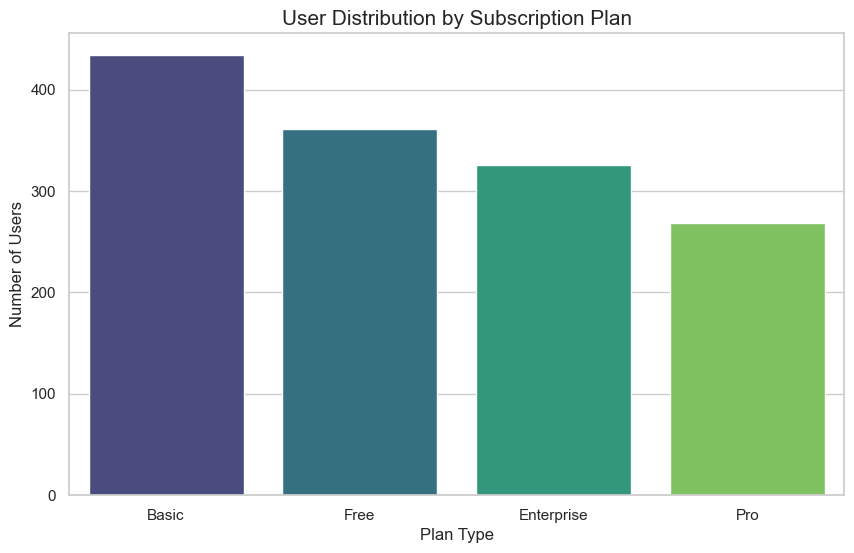

In [97]:
# Set aesthetic style
sns.set_theme(style="whitegrid")

# Distribution of Subscription Plans (Single Variable) ---
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='plan', palette='viridis', order=df['plan'].value_counts().index)
plt.title('User Distribution by Subscription Plan', fontsize=15)
plt.xlabel('Plan Type', fontsize=12)
plt.ylabel('Number of Users', fontsize=12)
plt.show()

The bar chart on **user distribution by subscription plan** shows that the **Basic plan** has the largest user base, slightly above 400, followed by the **Free plan** with around 350 users, then the **Enterprise plan** at about 325, and finally the **Pro plan** with the smallest group of roughly 275 users. This distribution suggests that most customers prefer either the entry-level paid option (Basic) or the free tier, reflecting a strong appeal to cost-conscious users. The Enterprise plan, despite its higher price, still attracts a significant number of users, likely larger organizations, while the Pro plan has the least adoption, indicating it may not provide enough differentiation or perceived value compared to Basic and Enterprise. The key insight is that customer adoption is strongest at the extremes low-cost or premium tiers while the mid-tier Pro plan struggles to gain traction, signaling a potential need to reevaluate its positioning or feature set.

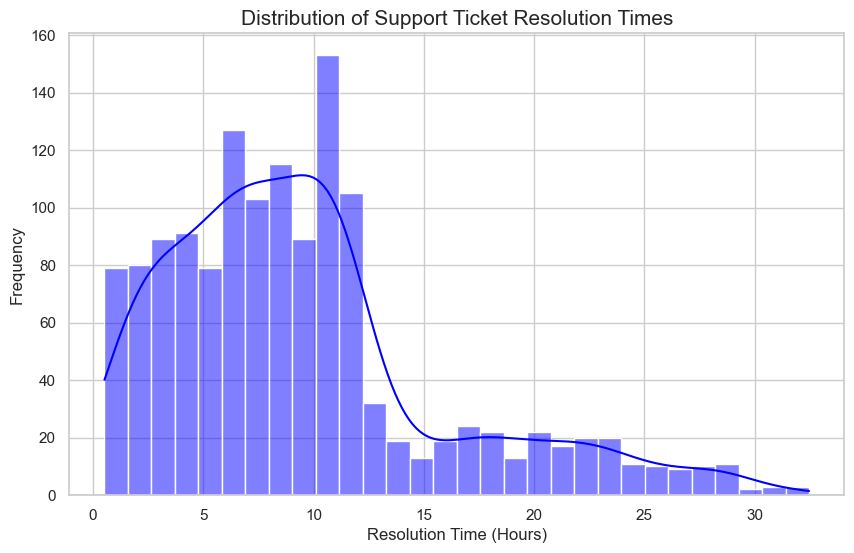

In [98]:
# Distribution of Resolution Times (Single Variable) ---
plt.figure(figsize=(10, 6))
sns.histplot(df['resolution_time_hours'], kde=True, color='blue', bins=30)
plt.title('Distribution of Support Ticket Resolution Times', fontsize=15)
plt.xlabel('Resolution Time (Hours)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.show()

The histogram on **support ticket resolution times** shows that most tickets are resolved within about **10 hours**, where the distribution peaks. After this point, the frequency of resolutions gradually declines, indicating fewer tickets take longer to close. While some tickets extend toward the 30-hour mark, these are less common and represent outliers. The insight here is that the majority of customer issues are handled relatively quickly, suggesting efficiency in the support process, but there is still a noticeable tail of longer resolution times that could point to complex cases often billing or account-related that require more attention. Overall, the data highlights strong responsiveness for most tickets, with opportunities to reduce delays in the small proportion of extended cases.

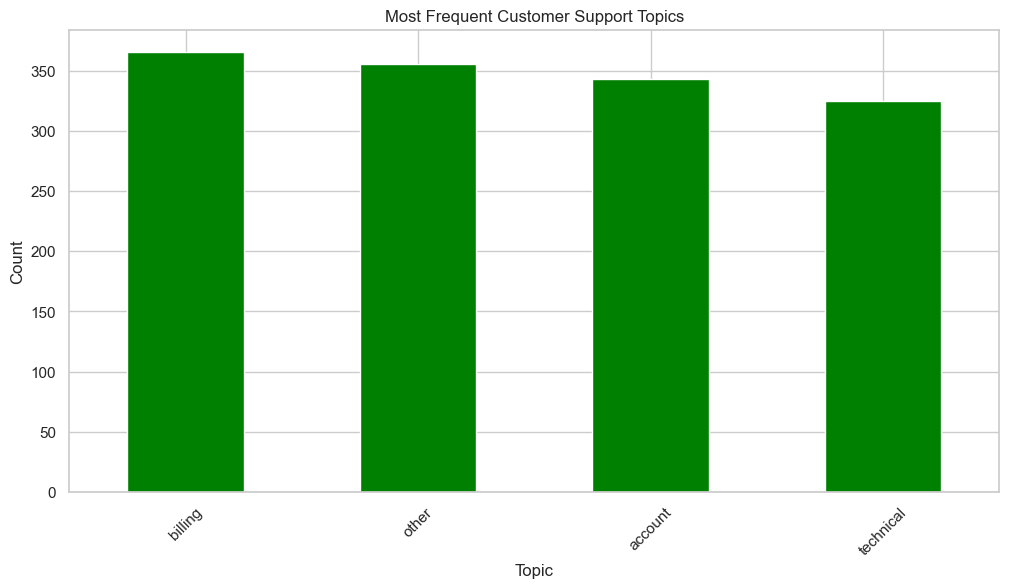

In [99]:
# Support Topic Frequency
plt.figure(figsize=(12, 6))
df['topic'].value_counts().plot(kind='bar', color='green')
plt.title('Most Frequent Customer Support Topics')
plt.xlabel('Topic')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

The bar chart on **most frequent customer support topics** shows that **billing issues** are the most common, slightly above 350 tickets, followed closely by the “other” category, then **account-related queries** at around 340, and finally **technical issues** at about 320. This distribution highlights that billing concerns dominate customer support demand, making them the top priority for resource allocation and process improvement. The near-equal frequency of “other”, account, and technical topics suggests that customers face a wide range of challenges beyond billing, but none as pressing. The key insight is that while support needs are diverse, billing consistently drives the highest volume of interactions, signaling that improvements in billing processes and clarity could significantly reduce overall support load and enhance customer satisfaction.

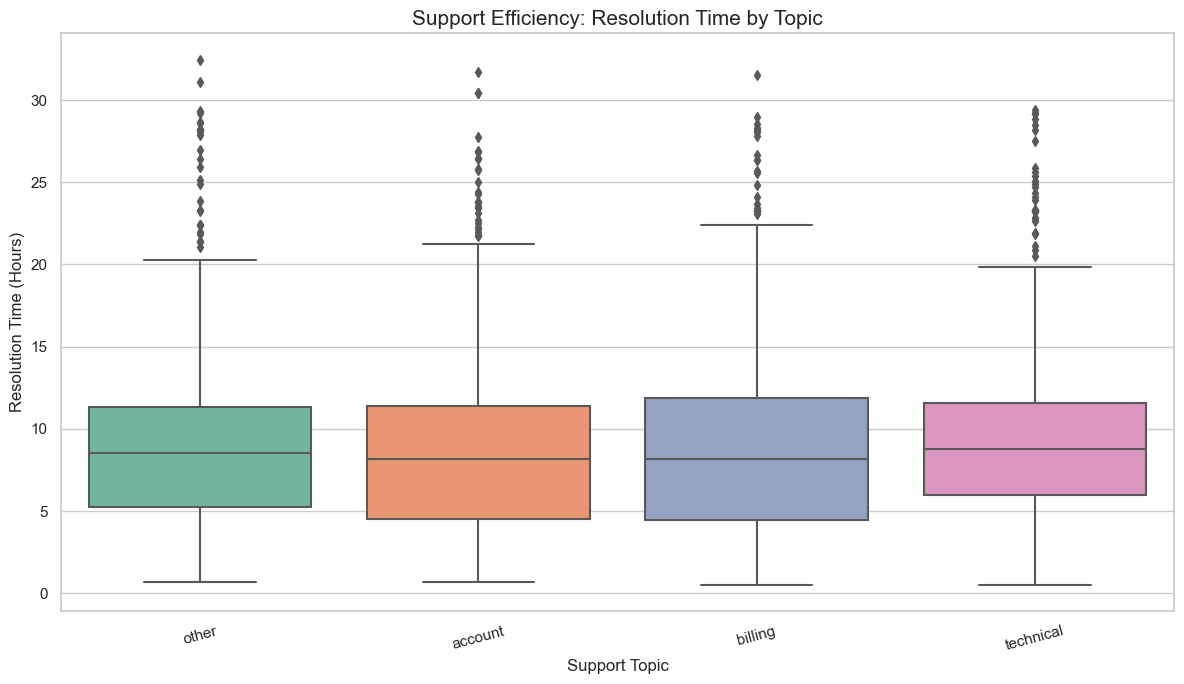

In [100]:
# Resolution Time by Support Topic (Two Variables) ---
plt.figure(figsize=(12, 7))
sns.boxplot(data=df, x='topic', y='resolution_time_hours', palette='Set2')
plt.title('Support Efficiency: Resolution Time by Topic', fontsize=15)
plt.xlabel('Support Topic', fontsize=12)
plt.ylabel('Resolution Time (Hours)', fontsize=12)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

The box plot on **support efficiency by resolution time across topics** highlights clear differences in how quickly issues are resolved depending on the category. **Billing tickets** show the widest spread, with resolution times ranging from very short to quite long, indicating inconsistency and potential inefficiencies in handling financial concerns. In contrast, **technical** and **other** topics have narrower distributions, suggesting more predictable and stable resolution times, while **account-related issues** fall somewhere in between. The key insight is that billing not only generates the highest ticket volume but also takes the most variable time to resolve, making it a critical area for improvement. Streamlining billing processes could reduce delays and improve customer satisfaction, while technical and other issues appear to be managed more consistently and efficiently.

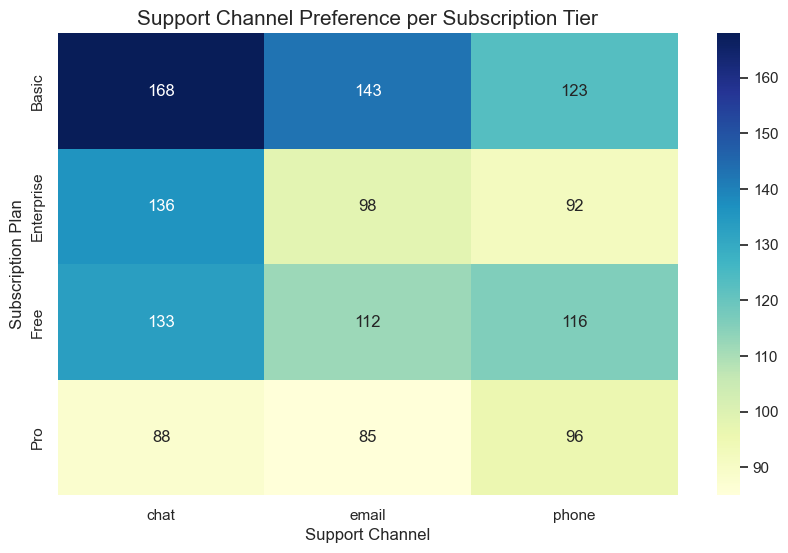

In [101]:
# Support Channel Usage by Plan (Multiple Variables) ---
plan_channel_matrix = pd.crosstab(df['plan'], df['channel'])
plt.figure(figsize=(10, 6))
sns.heatmap(plan_channel_matrix, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Support Channel Preference per Subscription Tier', fontsize=15)
plt.xlabel('Support Channel', fontsize=12)
plt.ylabel('Subscription Plan', fontsize=12)
plt.show()

The heatmap on **support channel preference per subscription tier** reveals interesting differences in how customers interact with support. **Basic plan users** show the strongest preference for chat (168), followed by email (143) and phone (123), suggesting that entry-level paid customers value quick, real-time assistance. **Enterprise users** also lean toward chat (136), but their overall engagement across channels is lower compared to Basic, reflecting that they may rely more on dedicated account management or customized support. **Free plan users** are fairly balanced across channels, with chat (133), email (112), and phone (116) showing similar usage, indicating diverse preferences among non-paying customers. **Pro users** have the lowest engagement overall, with relatively even but smaller counts across chat (88), email (85), and phone (96), suggesting this tier is less active in seeking support.  

The key insight is that **chat dominates across all tiers**, especially among Basic customers, while Pro users stand out for their lower support activity. This highlights that real-time digital support is critical for customer satisfaction, particularly for entry-level paid plans, whereas Enterprise customers may require more tailored solutions beyond standard channels.

### ==========================================
### 3. Metric Calculation
### ==========================================

Current Baseline Metric (ART): 9.46 hours


C:\Users\hp\AppData\Local\Temp\ipykernel_26236\2504737236.py:6: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x='channel', y='resolution_time_hours', palette='magma', ci=None)


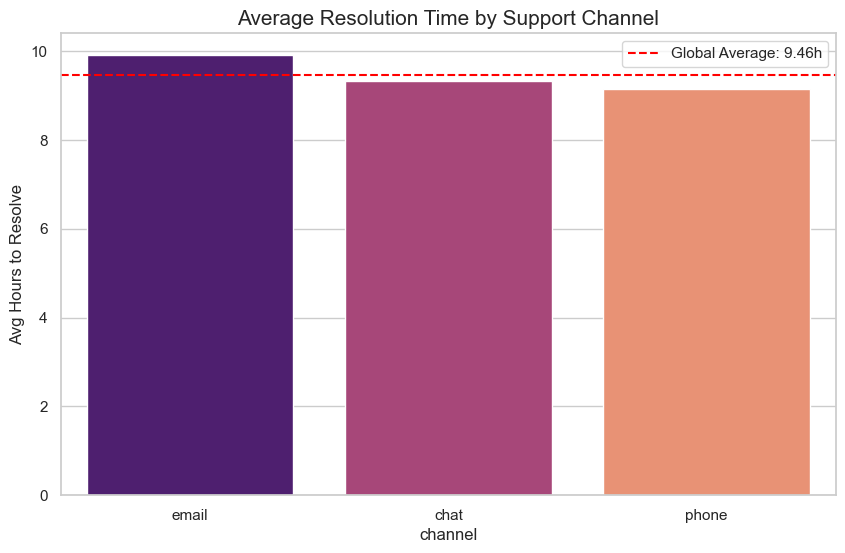

In [102]:
# Monitoring Average Resolution Time (ART)
art_value = df['resolution_time_hours'].mean()
print(f"Current Baseline Metric (ART): {art_value:.2f} hours")
# # Recommendation Visualization: Identifying the most efficient channels
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='channel', y='resolution_time_hours', palette='magma', ci=None)
plt.axhline(art_value, color='red', linestyle='--', label=f'Global Average: {art_value:.2f}h')
plt.title('Average Resolution Time by Support Channel', fontsize=15)
plt.ylabel('Avg Hours to Resolve', fontsize=12)
plt.legend()
plt.show()

The bar chart on **average resolution time by support channel** shows that **email support** takes the longest to resolve, averaging slightly above 9.5 hours, while **chat** and **phone** are marginally faster but still close to the global average of 9.46 hours. This indicates that although resolution times are fairly consistent across channels, email tends to be slower, likely due to the asynchronous nature of communication and the need for back-and-forth clarification. In contrast, chat and phone provide more immediate interaction, helping reduce delays. The key insight is that while overall efficiency is steady across channels, prioritizing improvements in email workflows such as automation or clearer templates could help bring resolution times closer to the faster, real-time channels and enhance customer satisfaction.

### ==========================================
### 4. Conclusion And Recommendations
### ==========================================

#### Conclusion
The data shows that customers on Free and Pro plans are more likely to leave compared to those on plans Basic and Enterprise . Many of the churn cases are linked to billing or technical problems, especially when customers use email or  support. Another clear pattern is that when support tickets take a long time to resolve often more than 20 hours customers are more likely to churn. In contrast, customers who use features like tracking or sharing workouts tend to stay longer, while those who mainly read articles or watch videos are more likely to leave. Some states, such as Louisiana and Connecticut, show clusters of churn tied to billing and technical issues, while states with more workout-related activity show better retention.

#### Recommendations
1. To reduce churn, the company should focus on improving support efficiency, especially for billing and technical issues. 
2. Faster resolution times will make customers feel more valued and less frustrated. Plans like Basic and Enterprise may need to be restructured or bundled with more engaging features to increase their appeal. 
3. Support channels like phone and chat should be strengthened with better training and quicker escalation. 
4. Finally, encouraging customers to use interactive features like workout tracking and sharing can help build stronger engagement and loyalty. Targeted retention campaigns in high-churn states could also make a difference.